# Day 03：金鱼的诅咒 —— RNN 的梯度消失问题> ⏳ 第九周 · 记忆的诞生 · 第 3 天昨天我们给神经网络装上了记忆——RNN 的隐藏状态。看起来很完美，对吧？但 RNN 有一个致命的弱点：**它的记忆是"金鱼记忆"——只能记住最近几步，再远的信息就忘了。**还记得阶段三的梯度消失吗？它又回来了，而且这次是在时间维度上。**今天的任务**：1. 理解 RNN 的梯度消失：为什么长距离依赖这么难2. 用代码验证：RNN 只能记住最近的信息3. 数学直觉：tanh 的梯度压缩效应---

## 1. 历史剧场：RNN 的"7秒记忆"1991 年，Hochreiter（LSTM 的发明者之一）在他的毕业论文中指出了一个根本问题：> **RNN 在训练长序列时，梯度要么消失，要么爆炸。**这意味着 RNN 虽然理论上可以记住任意长的历史，但实际上只能记住最近几步。就像一条金鱼，理论上它可以活很多年，但每 7 秒就忘掉之前的一切。这个问题被称为**长距离依赖问题（Long-term Dependency Problem）**。---

## 2. 生活隐喻：传话游戏的升级版还记得阶段四的"传话游戏"吗？RNN 的梯度消失就是它的升级版：- **短句子**："我喜欢猫" → RNN 能轻松理解- **长句子**："我出生在一个__的小镇，后来搬到了大城市，在那里遇到了__，我们成为了好朋友" → RNN 读到后面，已经忘了前面填的是什么这就像传话游戏：信息每经过一步，就被"压缩"一次（tanh 把值压到 [-1, 1]），经过多步后，早期的信息就被彻底磨平了。**更具体的比喻**：想象你在写一篇文章，但每写一个新段落，就必须把之前所有内容**浓缩成一句话**。写 10 段之后，第一段的细节早就丢失了。---

<p align="center">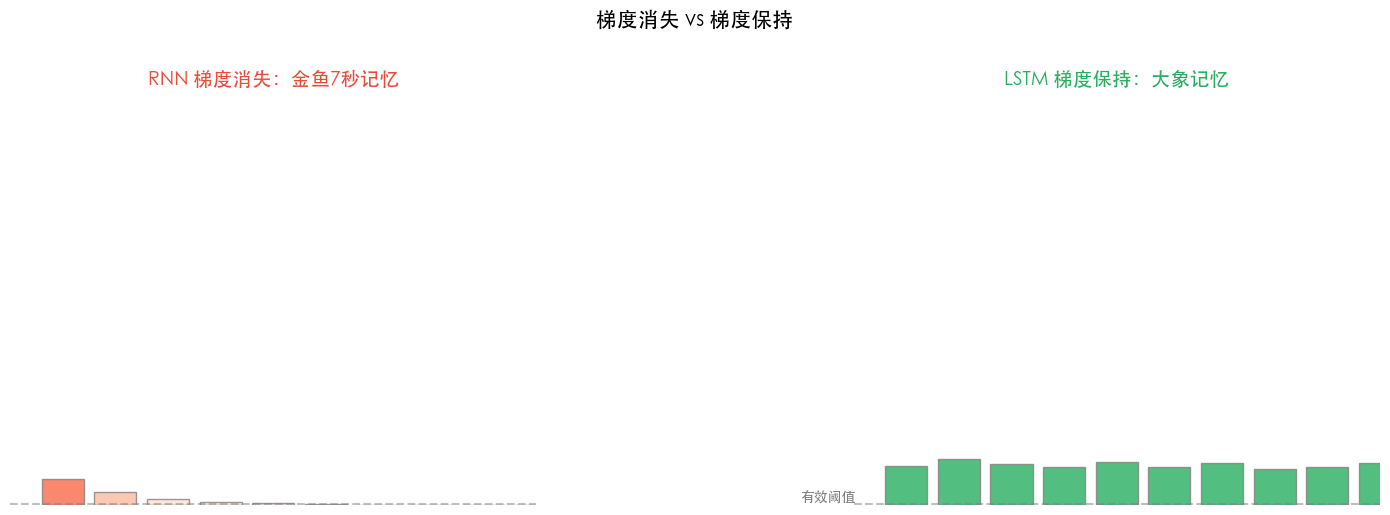</p>*RNN梯度消失 vs LSTM梯度保持对比图*

## 3. 数学直觉：为什么 tanh 会"遗忘"RNN 的核心公式：$$h_t = \tanh(W_{xh} x_t + W_{hh} h_{t-1} + b)$$反向传播时，梯度需要从 $h_t$ 传回 $h_{t-1}$，再传回 $h_{t-2}$……每传一步，都要乘以：$$\frac{\partial h_t}{\partial h_{t-1}} = W_{hh}^T \cdot \text{diag}(1 - h_t^2)$$其中 $\text{diag}(1 - h_t^2)$ 是 tanh 的导数。因为 $h_t \in [-1, 1]$，所以 $1 - h_t^2 \in [0, 1]$。**关键**：每一步，梯度都要乘以一个小于 1 的数。经过 T 步后：$$\text{梯度} \propto \prod_{t=1}^{T} (1 - h_t^2) \approx (0.5)^T$$如果序列长度 T = 50，梯度大约变成 $0.5^{50} \approx 10^{-15}$——基本为零。---

## 4. 代码实验室：亲眼见证梯度消失

In [ ]:
import torchimport torch.nn as nnimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 4.1 构造长距离依赖任务我们构造一个任务：序列开头有一个关键信息，模型需要在序列末尾回忆起来。

In [ ]:
def create_long_dependency_data(seq_len=50, n_samples=200):    np.random.seed(42)    X = np.random.randn(n_samples, seq_len, 1)    y = np.zeros((n_samples, 1))    for i in range(n_samples):        key_value = X[i, 0, 0]        y[i, 0] = 1.0 if key_value > 0 else 0.0        noise = np.random.randn(seq_len, 1) * 0.3        X[i] = X[i] + noise    return (torch.tensor(X, dtype=torch.float32),            torch.tensor(y, dtype=torch.float32))X_short, y_short = create_long_dependency_data(seq_len=10)X_long, y_long = create_long_dependency_data(seq_len=50)print(f"短序列: X={X_short.shape}, 长序列: X={X_long.shape}")print(f"任务: 根据序列第1个元素的正负，预测标签")

### 4.2 用 PyTorch 的 RNN 来测试

In [ ]:
class SimpleRNN(nn.Module):    def __init__(self, input_size=1, hidden_size=32):        super().__init__()        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)        self.fc = nn.Linear(hidden_size, 1)    def forward(self, x):        _, h_n = self.rnn(x)        return torch.sigmoid(self.fc(h_n.squeeze(0)))def train_rnn(model, X, y, epochs=200, lr=0.01):    optimizer = torch.optim.Adam(model.parameters(), lr=lr)    loss_fn = nn.BCELoss()    losses = []    for epoch in range(epochs):        pred = model(X)        loss = loss_fn(pred, y)        optimizer.zero_grad()        loss.backward()        optimizer.step()        losses.append(loss.item())    acc = ((pred > 0.5).float() == y).float().mean()    return losses, acc.item()torch.manual_seed(42)short_model = SimpleRNN()short_losses, short_acc = train_rnn(short_model, X_short, y_short)torch.manual_seed(42)long_model = SimpleRNN()long_losses, long_acc = train_rnn(long_model, X_long, y_long)print(f"短序列 (T=10) 准确率: {short_acc:.2%}")print(f"长序列 (T=50) 准确率: {long_acc:.2%}")

### 4.3 可视化：序列越长，记忆越差

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))axes[0].plot(short_losses, label='短序列 (T=10)', color='#27ae60', alpha=0.8)axes[0].plot(long_losses, label='长序列 (T=50)', color='#e74c3c', alpha=0.8)axes[0].set_xlabel('Epoch', fontsize=12)axes[0].set_ylabel('Loss', fontsize=12)axes[0].set_title('训练损失对比', fontsize=14)axes[0].legend(fontsize=12)axes[0].grid(True, alpha=0.3)seq_lengths = [5, 10, 20, 30, 50, 80]accuracies = []for sl in seq_lengths:    X_test, y_test = create_long_dependency_data(seq_len=sl, n_samples=200)    torch.manual_seed(42)    m = SimpleRNN()    _, acc = train_rnn(m, X_test, y_test, epochs=200)    accuracies.append(acc)axes[1].plot(seq_lengths, accuracies, 'o-', color='#3498db', markersize=10, lw=2)axes[1].set_xlabel('序列长度', fontsize=12)axes[1].set_ylabel('准确率', fontsize=12)axes[1].set_title('序列越长，RNN 记忆越差', fontsize=14)axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='随机猜测')axes[1].legend(fontsize=11)axes[1].grid(True, alpha=0.3)plt.tight_layout()plt.show()

### 解读- **短序列**：RNN 还能记住开头的信息，准确率不错- **长序列**：RNN 忘了开头的信息，准确率接近随机猜测（50%）- **趋势图**：序列越长，准确率越低——这就是"金鱼记忆"的诅咒---

## 5. 梯度消失的定量分析

In [ ]:
print("RNN 梯度消失的定量分析\n")print("tanh 导数的最大值 = 1.0 (当 h_t = 0 时)")print("tanh 导数的典型值 ≈ 0.5 (当 h_t ≈ 0.7 时)")print()for T in [5, 10, 20, 50, 100]:    grad = 0.5 ** T    print(f"序列长度 T={T:3d}: 梯度 ≈ 0.5^{T} = {grad:.2e}")print()print("结论: 序列长度超过 20 步后，梯度几乎为零")print("      RNN 无法学习长距离依赖关系")

---

## 今日结语今天我们发现了 RNN 的致命弱点：**梯度消失让它的记忆只有"7秒"**。虽然理论上 RNN 可以记住任意长的序列，但实际上 tanh 的梯度压缩效应让远距离的信息无法传回来。序列越长，RNN 越健忘。这个问题困扰了研究者整整十年（1991-2001），直到两个人提出了一个天才的想法——给记忆加一个"传送门"。那就是明天要讲的——**LSTM 的门控机制**。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 金鱼7秒记忆 | RNN 梯度消失——只能记住最近几步 || 传话游戏——信息越传越走样 | 梯度在时间步中逐步衰减 || 每写一段就要浓缩之前内容 | tanh 把隐藏状态压缩到 [-1, 1] || 序列越长越健忘 | 长距离依赖问题 || 需要一种"不受压缩影响"的记忆通道 | LSTM 的细胞状态（预告！） |